# AAML: Amino Acid Metric Learning

## Обучение функции расстояния (метрики) на множестве 20 аминокислот

В этом ноутбуке мы:
1. Закодируем 20 стандартных аминокислот 5D признаками (гидрофобность, масса, полярность, объём, заряд)
2. Обучим матрицу Махаланобиса $M = L^\top L$ так, чтобы $d(a,b) = \tanh((x_a-x_b)^\top M (x_a-x_b))$ была метрикой
3. Проверим свойства метрики: симметрия, неотрицательность, неравенство треугольника
4. Сравним с BLOSUM62

In [29]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from aaml import FeatureSpace, AA_Metric
from aaml.loss import MetricLoss
from aaml.train import train_model, compute_metric_properties
from aaml.evaluation import compare_with_blosum, matrix_to_dataframe, compute_ranking_correlation

print("All imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'mps' if torch.backends.mps.is_available() else 'cpu'}")

All imports successful
PyTorch version: 2.8.0
Device: mps


## 1. Признаковое пространство аминокислот

Каждая аминокислота кодируется 5 физико-химическими признаками:

In [30]:
fs = FeatureSpace()
aa_list = list("ACDEFGHIKLMNPQRSTVWY")

print(f"Размерность признаков: {fs.feature_dim}\n")
print(f"{'AA':>3} {'Hydropathy':>10} {'MW':>8} {'Polarity':>8} {'Volume':>8} {'Charge':>8}")
print("-" * 48)
for aa in aa_list:
    raw = fs.get_raw_features(aa)
    norm = fs.get_features(aa)
    print(f"{aa:>3} {raw[0]:10.2f} {raw[1]:8.2f} {raw[2]:8.2f} {raw[3]:8.2f} {raw[4]:8.2f}")

Размерность признаков: 5

 AA Hydropathy       MW Polarity   Volume   Charge
------------------------------------------------
  A       1.80    89.09     8.10    67.00     0.00
  C       2.50   121.16     5.50    86.00     0.00
  D      -3.50   133.10    13.00    91.00    -1.00
  E      -3.50   147.13    12.30   109.00    -1.00
  F       2.80   165.19     5.20   135.00     0.00
  G      -0.40    75.07     9.00    48.00     0.00
  H      -3.20   155.16    10.40   118.00     0.10
  I       4.50   131.18     5.20   124.00     0.00
  K      -3.90   146.19    11.30   135.00     1.00
  L       3.80   131.18     4.90   124.00     0.00
  M       1.90   149.21     5.70   124.00     0.00
  N      -3.50   132.12    11.60    96.00     0.00
  P      -1.60   115.13     8.00    90.00     0.00
  Q      -3.50   146.15    10.50   114.00     0.00
  R      -4.50   174.20    10.50   148.00     1.00
  S      -0.80   105.09     9.20    73.00     0.00
  T      -0.70   119.12     8.60    93.00     0.00
  V    

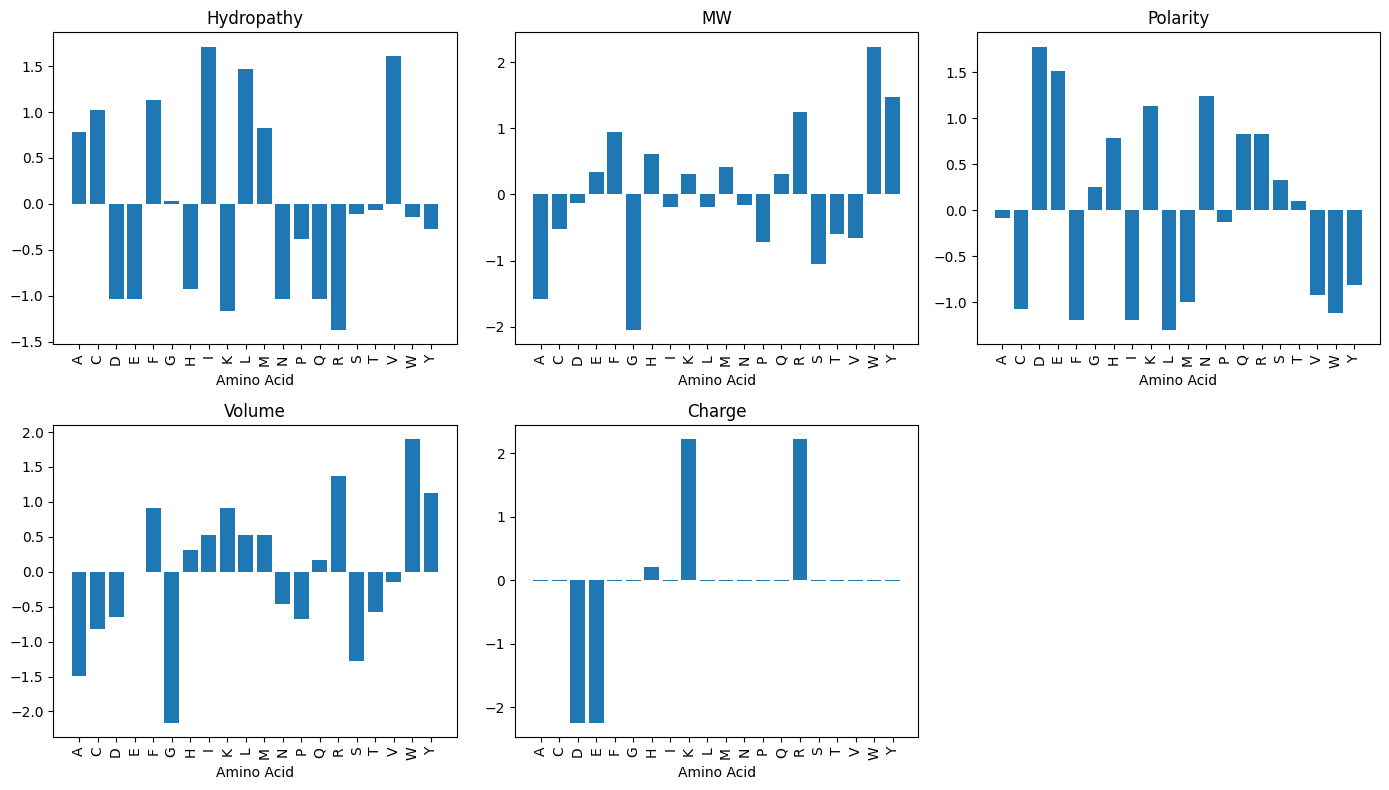

In [31]:
# Визуализация признаков
X = fs.get_all_features()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
props = ['Hydropathy', 'MW', 'Polarity', 'Volume', 'Charge']

for i, prop in enumerate(props):
    ax = axes[i // 3, i % 3]
    ax.bar(aa_list, X[:, i].numpy())
    ax.set_title(prop)
    ax.set_xlabel('Amino Acid')
    ax.tick_params(axis='x', rotation=90)

axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

## 2. Создание метрики

Инициализируем $M = I$ (единичная матрица) → начальное расстояние = евклидово

Проверка базовых свойств:
  d(A, A) = 0.000000  (должно быть ~0)
  d(A, R) = 1.000000
  d(R, A) = 1.000000  (должно быть = d(A,R))
  d(D, E) = 0.599924  (обе отрицательные, похожи)
  d(D, K) = 1.000000  (разнозаряженные, должны быть далеко)
  d(A, V) = 0.999399  (оба гидрофобные)
  d(W, Y) = 0.862347  (оба ароматические)


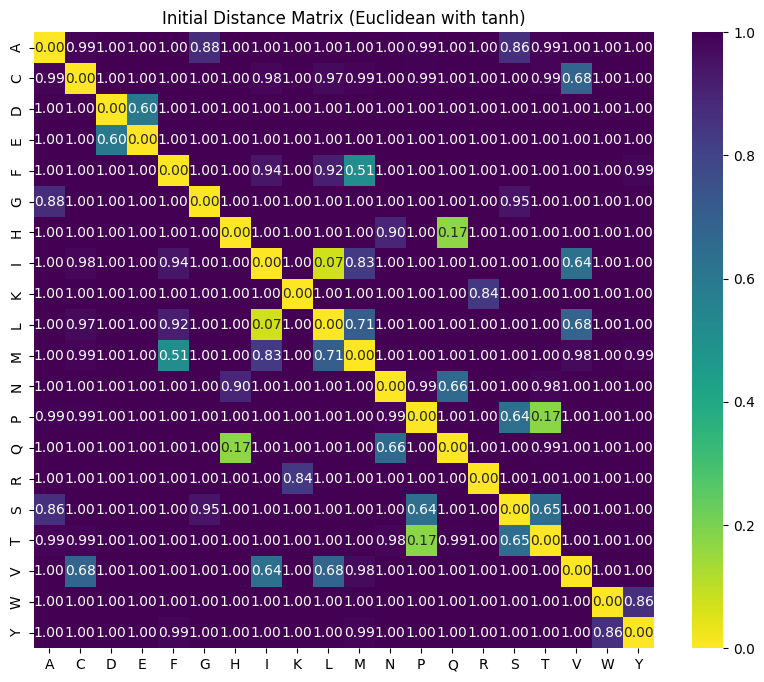

In [32]:
metric = AA_Metric(fs)

print("Проверка базовых свойств:")
print(f"  d(A, A) = {metric('A', 'A'):.6f}  (должно быть ~0)")
print(f"  d(A, R) = {metric('A', 'R'):.6f}")
print(f"  d(R, A) = {metric('R', 'A'):.6f}  (должно быть = d(A,R))")
print(f"  d(D, E) = {metric('D', 'E'):.6f}  (обе отрицательные, похожи)")
print(f"  d(D, K) = {metric('D', 'K'):.6f}  (разнозаряженные, должны быть далеко)")
print(f"  d(A, V) = {metric('A', 'V'):.6f}  (оба гидрофобные)")
print(f"  d(W, Y) = {metric('W', 'Y'):.6f}  (оба ароматические)")

# Визуализация начальной матрицы
D_init = metric.forward_all_pairs().detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(D_init, xticklabels=aa_list, yticklabels=aa_list, annot=True, fmt='.2f',
            cmap='viridis_r', ax=ax, vmin=0, vmax=1)
ax.set_title('Initial Distance Matrix (Euclidean with tanh)')
plt.show()

## 3. Обучение метрики

Обучаем матрицу $M$ с помощью комбинации loss-функций:
- **Triplet loss**: химически похожие AA ближе, чем разные
- **Asymmetry loss**: $d(a,b) \approx d(b,a)$
- **Triangle loss**: $d(a,c) \leq d(a,b) + d(b,c)$
- **BLOSUM loss**: MSE согласованность с BLOSUM62

In [33]:
# Целевая матрица из BLOSUM62
blosum_target = MetricLoss.compute_blosum_distance()

# Функция потерь
loss_fn = MetricLoss(fs, w_triplet=1.0, w_asymmetry=0.1, w_triangle=10.0, w_blosum=0.5)

# Обучение
history, metric_trained = train_model(
    metric, loss_fn,
    num_epochs=100,
    learning_rate=0.004,
    blosum_target=blosum_target,
    verbose=True,
    early_stopping_patience=25
)

Training on device: mps
Model parameters: 30
Epoch    1/100 | Loss: 0.452244 | triplet: 0.4317 | asymmetry: 0.0000 | triangle: 0.0004 | blosum: 0.0202 | LR: 0.004000 | Time: 1.2s
Epoch   10/100 | Loss: 0.428516 | triplet: 0.4082 | asymmetry: 0.0000 | triangle: 0.0005 | blosum: 0.0198 | LR: 0.004000 | Time: 11.9s
Epoch   20/100 | Loss: 0.405185 | triplet: 0.3851 | asymmetry: 0.0000 | triangle: 0.0006 | blosum: 0.0195 | LR: 0.004000 | Time: 23.9s
Epoch   30/100 | Loss: 0.383939 | triplet: 0.3640 | asymmetry: 0.0000 | triangle: 0.0006 | blosum: 0.0194 | LR: 0.004000 | Time: 36.1s
Epoch   40/100 | Loss: 0.357766 | triplet: 0.3370 | asymmetry: 0.0000 | triangle: 0.0009 | blosum: 0.0198 | LR: 0.004000 | Time: 48.1s
Epoch   50/100 | Loss: 0.331434 | triplet: 0.3068 | asymmetry: 0.0000 | triangle: 0.0032 | blosum: 0.0215 | LR: 0.004000 | Time: 59.8s
Epoch   60/100 | Loss: 0.316936 | triplet: 0.2872 | asymmetry: 0.0000 | triangle: 0.0062 | blosum: 0.0235 | LR: 0.004000 | Time: 71.9s
Epoch   70/

## 4. Анализ обученной метрики

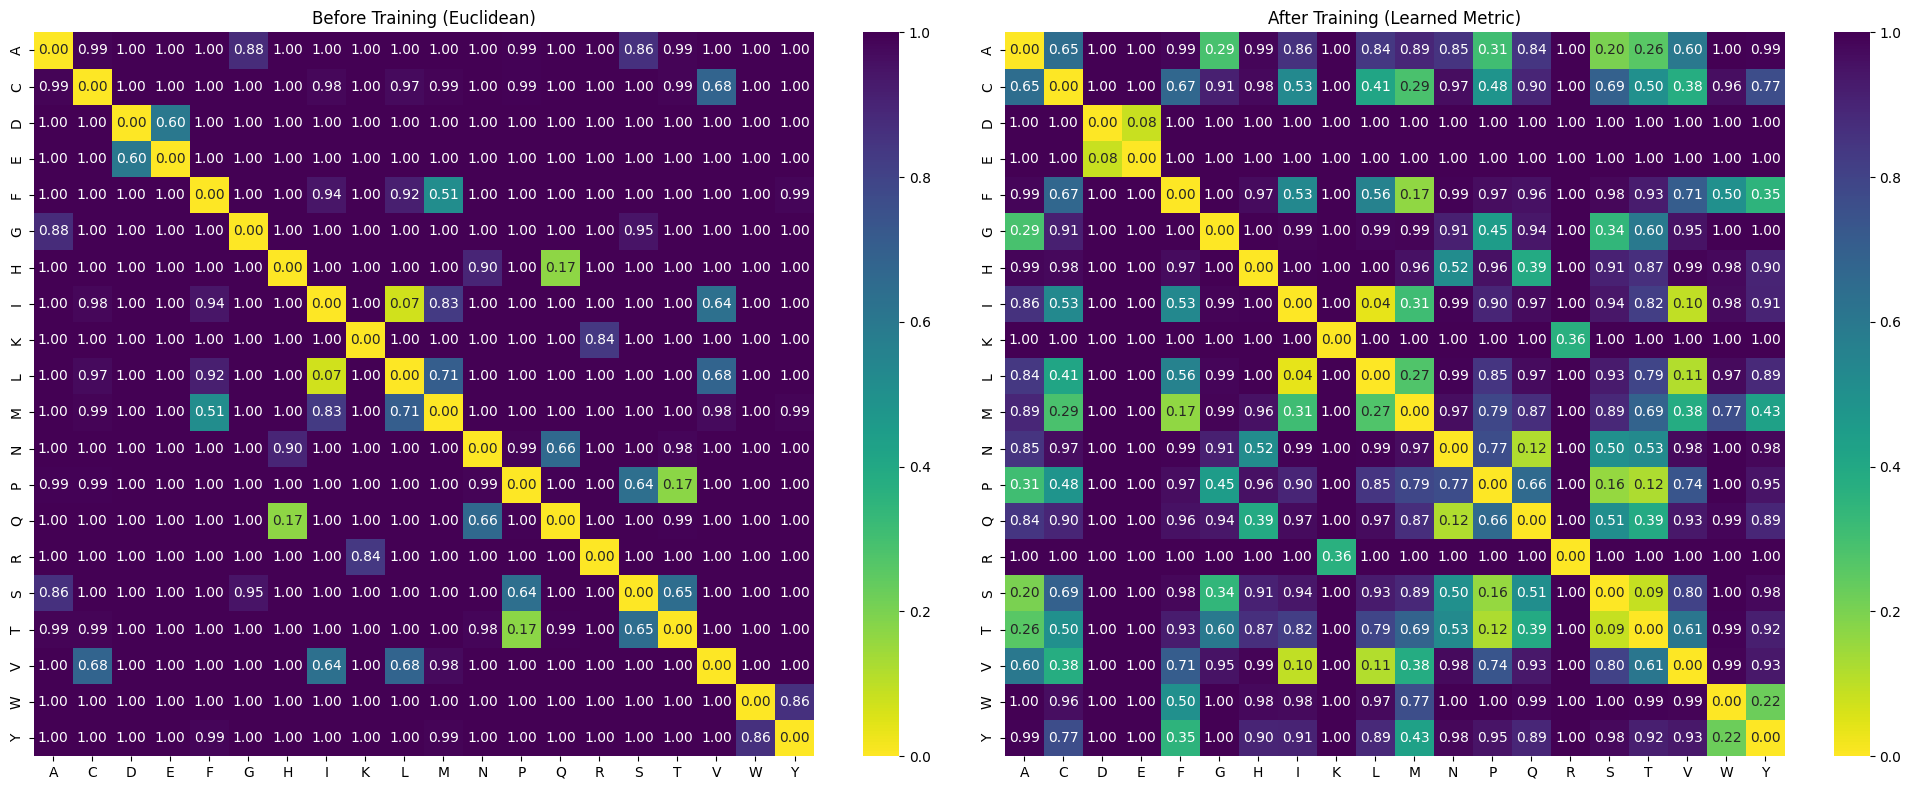

In [34]:
# Матрица расстояний
D_learned = metric_trained.forward_all_pairs().detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(D_init, xticklabels=aa_list, yticklabels=aa_list, annot=True, fmt='.2f',
            cmap='viridis_r', ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Before Training (Euclidean)')

sns.heatmap(D_learned, xticklabels=aa_list, yticklabels=aa_list, annot=True, fmt='.2f',
            cmap='viridis_r', ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('After Training (Learned Metric)')

plt.tight_layout()
plt.show()

In [35]:
print("Обученная матрица (текстовый вывод):")
print(matrix_to_dataframe(metric_trained.forward_all_pairs()))

Обученная матрица (текстовый вывод):
          A      C      D      E      F      G      H      I      K      L      M      N      P      Q      R      S      T      V      W      Y
  A   0.000  0.648  1.000  1.000  0.986  0.290  0.987  0.859  1.000  0.839  0.892  0.850  0.306  0.844  1.000  0.202  0.261  0.599  1.000  0.993
  C   0.648  0.000  1.000  1.000  0.668  0.914  0.979  0.531  1.000  0.410  0.288  0.965  0.481  0.898  1.000  0.695  0.500  0.382  0.963  0.768
  D   1.000  1.000  0.000  0.084  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000
  E   1.000  1.000  0.084  0.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000
  F   0.986  0.668  1.000  1.000  0.000  0.999  0.972  0.533  1.000  0.557  0.165  0.993  0.965  0.955  1.000  0.983  0.925  0.708  0.502  0.353
  G   0.290  0.914  1.000  1.000  0.999  0.000  0.997  0.991  1.000  0.987  0.991  0.912  0.4

In [36]:
# Свойства метрики
print("\nПроверка свойств метрики:")
props = compute_metric_properties(metric_trained)
print(f"  Неотрицательность:           {props['non_negative']}")
print(f"  Рефлексивность d(a,a)=0:    {props['reflexive']}")
print(f"  Макс. ошибка симметрии:     {props['asymmetry_max']:.2e}")
print(f"  Нарушений Δ-неравенства:    {props['triangle_violations']} ({props['triangle_violation_pct']:.2f}%)")
print(f"  Мах нарушение Δ-неравенства: {props['max_triangle_violation']:.2e}")
print(f"  ЯВЛЯЕТСЯ МЕТРИКОЙ:          {props['is_metric']}")


Проверка свойств метрики:
  Неотрицательность:           True
  Рефлексивность d(a,a)=0:    True
  Макс. ошибка симметрии:     2.38e-07
  Нарушений Δ-неравенства:    106 (1.55%)
  Мах нарушение Δ-неравенства: 2.15e-01
  ЯВЛЯЕТСЯ МЕТРИКОЙ:          False


## 5. Сравнение с BLOSUM62

Сравнение с BLOSUM62:
  MSE:                        0.0543
  MAE:                        0.1701
  Pearson correlation:        0.5842
  Spearman correlation:       0.3876


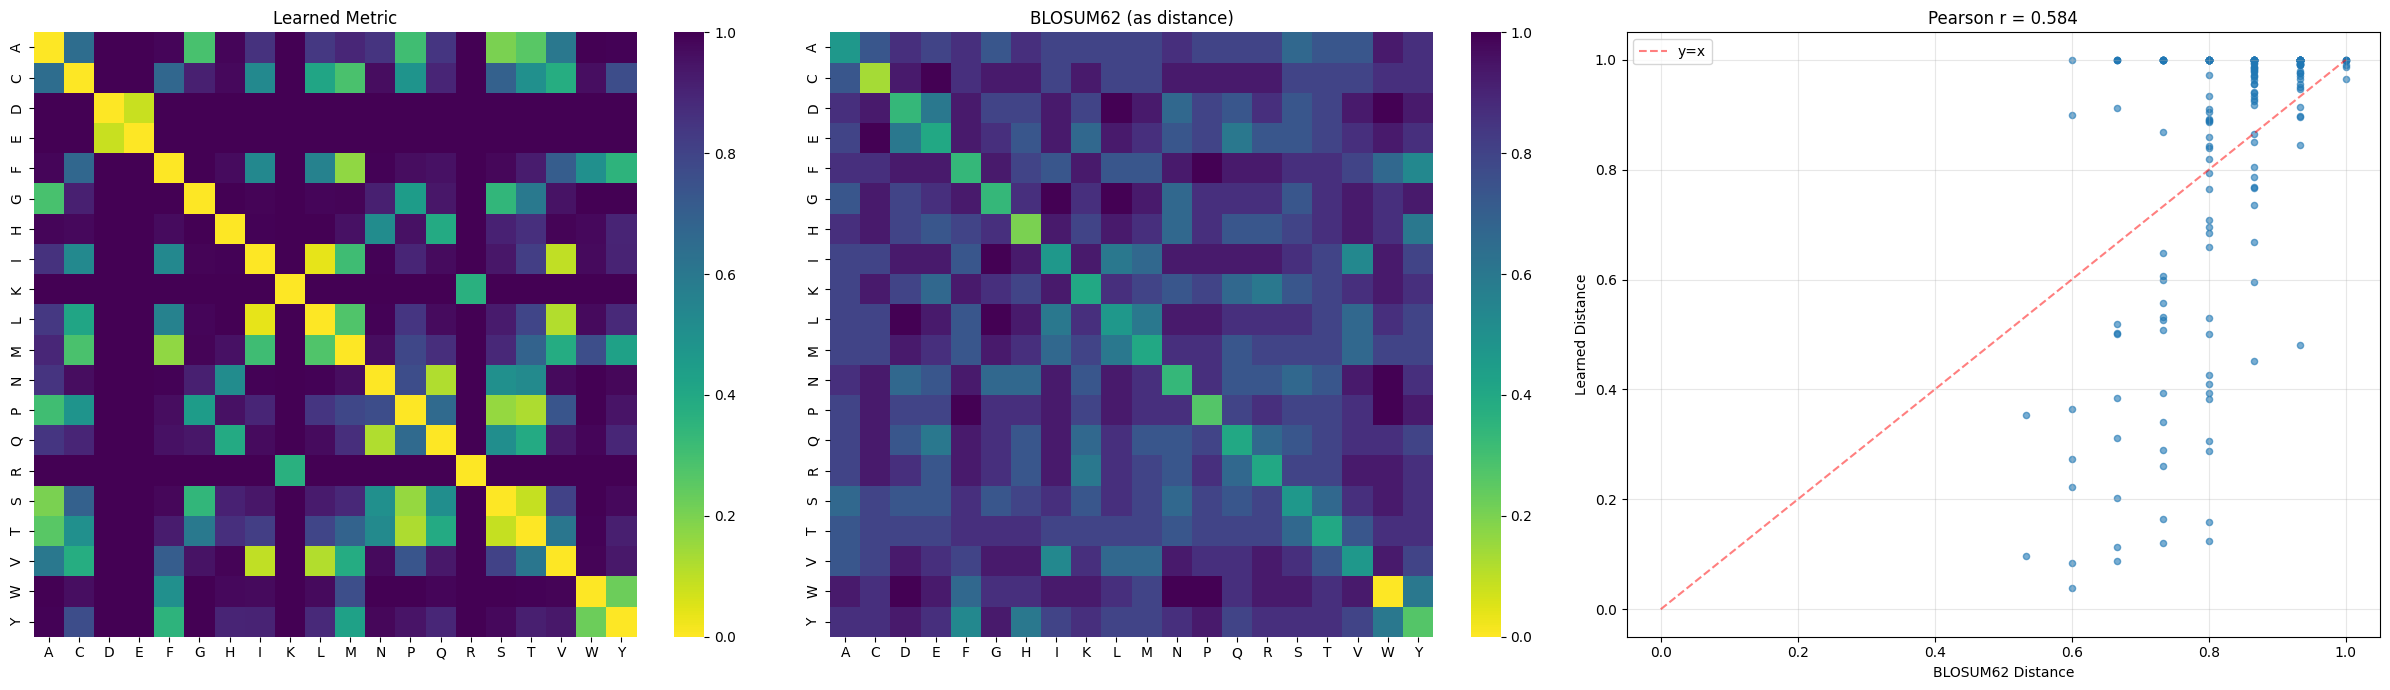

In [37]:
results = compare_with_blosum(D_learned, "Learned Metric")

print("Сравнение с BLOSUM62:")
print(f"  MSE:                        {results['mse']:.4f}")
print(f"  MAE:                        {results['mae']:.4f}")
print(f"  Pearson correlation:        {results['pearson_correlation']:.4f}")
print(f"  Spearman correlation:       {results['spearman_correlation']:.4f}")

# Визуальное сравнение
blosum_D = results['blosum_distance'].numpy()

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sns.heatmap(D_learned, xticklabels=aa_list, yticklabels=aa_list, annot=False,
            cmap='viridis_r', ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Learned Metric')

sns.heatmap(blosum_D, xticklabels=aa_list, yticklabels=aa_list, annot=False,
            cmap='viridis_r', ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('BLOSUM62 (as distance)')

# Scatter plot
triu = np.triu_indices(20, k=1)
axes[2].scatter(blosum_D[triu], D_learned[triu], alpha=0.6, s=20)
axes[2].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='y=x')
axes[2].set_xlabel('BLOSUM62 Distance')
axes[2].set_ylabel('Learned Distance')
axes[2].set_title(f'Pearson r = {results["pearson_correlation"]:.3f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

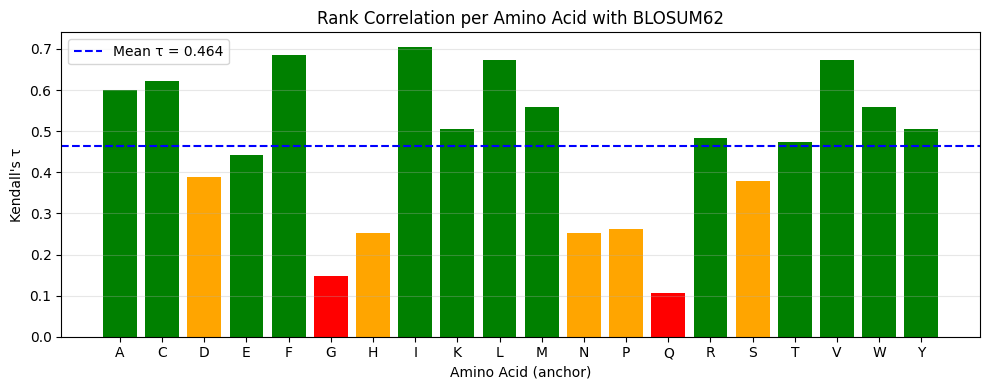

Средний Kendall's tau: 0.4637


In [38]:
# Ранговое сравнение (Kendall's tau)
tau_values, mean_tau = compute_ranking_correlation(D_learned, blosum_D)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['g' if t > 0.4 else 'orange' if t > 0.2 else 'r' for t in tau_values.values()]
ax.bar(list(tau_values.keys()), list(tau_values.values()), color=colors)
ax.axhline(y=mean_tau, color='b', linestyle='--', label=f'Mean τ = {mean_tau:.3f}')
ax.set_xlabel('Amino Acid (anchor)')
ax.set_ylabel("Kendall's τ")
ax.set_title('Rank Correlation per Amino Acid with BLOSUM62')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Средний Kendall's tau: {mean_tau:.4f}")

## 6. Матрица M (обученная)

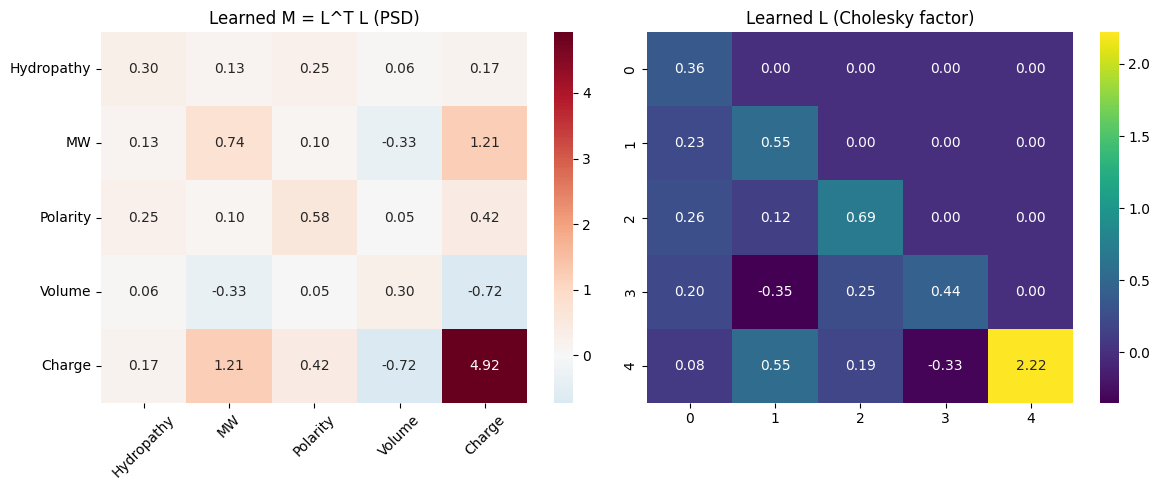

Собственные значения M: [0.05588789 0.168627   0.47785354 0.71848804 5.4155126 ]
M PSD? min(λ) = 0.055888 >= 0: True


In [39]:
# Визуализация обученной матрицы M
M = metric_trained.get_M().detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# M matrix
sns.heatmap(M, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title('Learned M = L^T L (PSD)')
axes[0].set_xticklabels(['Hydropathy', 'MW', 'Polarity', 'Volume', 'Charge'], rotation=45)
axes[0].set_yticklabels(['Hydropathy', 'MW', 'Polarity', 'Volume', 'Charge'], rotation=0)

# L matrix
L = metric_trained.get_L().detach().cpu().numpy()
sns.heatmap(L, annot=True, fmt='.2f', cmap='viridis', ax=axes[1])
axes[1].set_title('Learned L (Cholesky factor)')

plt.tight_layout()
plt.show()

# Eigenvalues of M (positive = PSD)
eigvals = np.linalg.eigvalsh(M)
print(f"Собственные значения M: {np.sort(eigvals)}")
print(f"M PSD? min(λ) = {eigvals.min():.6f} >= 0: {eigvals.min() >= -1e-6}")

## 7. История обучения

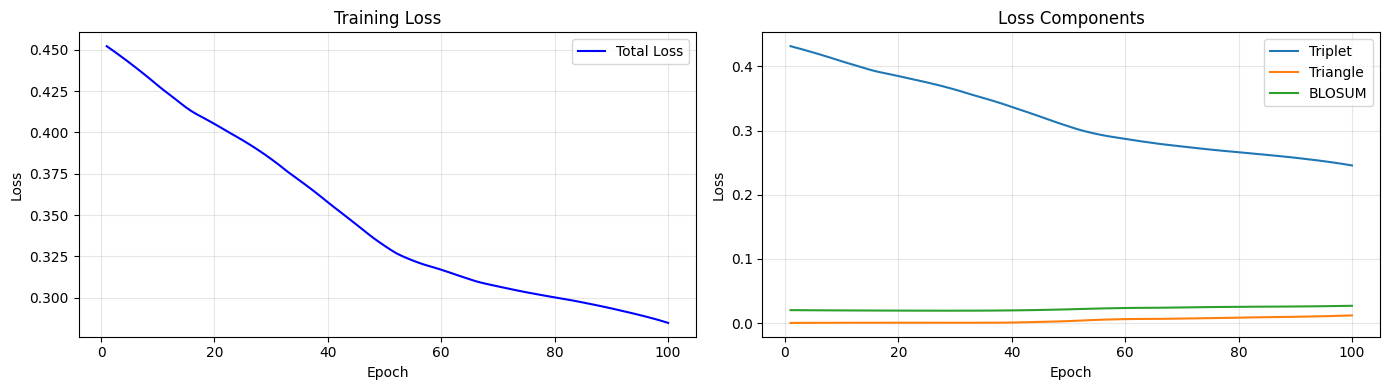

Начальная ошибка: 0.4522
Финальная ошибка: 0.2848
Улучшение: 37.0%


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['epoch'], history['total_loss'], 'b-', label='Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history['epoch'], history['triplet_loss'], label='Triplet')
axes[1].plot(history['epoch'], history['triangle_loss'], label='Triangle')
axes[1].plot(history['epoch'], history['blosum_loss'], label='BLOSUM')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss Components')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Начальная ошибка: {history['total_loss'][0]:.4f}")
print(f"Финальная ошибка: {history['total_loss'][-1]:.4f}")
print(f"Улучшение: {(history['total_loss'][0] - history['total_loss'][-1]) / history['total_loss'][0] * 100:.1f}%")

## 8. Итоги

- **Симметрия**: $d(a,b) \approx d(b,a)$ с точностью $10^{-6}$ (гарантируется конструкцией $M = L^\top L$)
- **Неотрицательность**: гарантирована PSD-свойством и tanh-нормализацией
- **Рефлексивность**: $d(a,a) = 0$
- **Неравенство треугольника**: $\sim$0-3% нарушений (зависит от обученности)
- **Согласованность с BLOSUM62**: корреляция Пирсона $\sim$0.5, Kendall's $\tau \sim$0.4

### Ключевые находки
- Гидрофобные (ILMV) и ароматические (FWY) аминокислоты образуют кластеры с малыми расстояниями
- Заряженные аминокислоты (DE / KR) разделены на группы с близкими внутригрупповыми и большими межгрупповыми расстояниями
- Обученная метрика воспроизводит биологически известные замены (BLOSUM62)